In [6]:
# Import important libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [7]:
# Load your downloaded file
df = pd.read_csv('TieredAffordability_Rental.csv')
df

,index,RegionID,RegionName,SizeRank,tier,date,income,zri,PercentIncomeSpentOnRent
0,0,394913,"New York, NY",1,Bottom Tier,2011-12-31,19250.000000,1503,0.936935
1,1,394913,"New York, NY",1,Upper Tier,2011-12-31,152000.000000,2908,0.229579
2,2,394913,"New York, NY",1,Bottom Tier,2012-03-31,19375.000000,1514,0.937703
3,3,394913,"New York, NY",1,Upper Tier,2012-03-31,153000.000000,2978,0.233569
4,4,394913,"New York, NY",1,Bottom Tier,2012-06-30,19500.000000,1526,0.939077
...,...,...,...,...,...,...,...,...,...
1708,1708,395045,"Sacramento, CA",25,Middle Tier,2015-06-30,62537.020000,1257,0.241201
1709,1709,395045,"Sacramento, CA",25,Middle Tier,2015-09-30,63189.060000,1283,0.243650
1710,1710,395045,"Sacramento, CA",25,Middle Tier,2015-12-31,63740.220000,1294,0.243614
1711,1711,395045,"Sacramento, CA",25,Middle Tier,2016-03-31,64209.112364,1324,0.247442


In [8]:
# First five rows of dataset
df.head()

,index,RegionID,RegionName,SizeRank,tier,date,income,zri,PercentIncomeSpentOnRent
0,0,394913,"New York, NY",1,Bottom Tier,2011-12-31,19250.0,1503,0.936935
1,1,394913,"New York, NY",1,Upper Tier,2011-12-31,152000.0,2908,0.229579
2,2,394913,"New York, NY",1,Bottom Tier,2012-03-31,19375.0,1514,0.937703
3,3,394913,"New York, NY",1,Upper Tier,2012-03-31,153000.0,2978,0.233569
4,4,394913,"New York, NY",1,Bottom Tier,2012-06-30,19500.0,1526,0.939077


In [9]:
# Last five rows of dataset
df.tail()

,index,RegionID,RegionName,SizeRank,tier,date,income,zri,PercentIncomeSpentOnRent
1708,1708,395045,"Sacramento, CA",25,Middle Tier,2015-06-30,62537.020000,1257,0.241201
1709,1709,395045,"Sacramento, CA",25,Middle Tier,2015-09-30,63189.060000,1283,0.243650
1710,1710,395045,"Sacramento, CA",25,Middle Tier,2015-12-31,63740.220000,1294,0.243614
1711,1711,395045,"Sacramento, CA",25,Middle Tier,2016-03-31,64209.112364,1324,0.247442
1712,1712,395045,"Sacramento, CA",25,Middle Tier,2016-06-30,64678.004727,1350,0.250472


In [10]:
# To understand data types and missing values in dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1713 entries, 0 to 1712
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     1713 non-null   int64  
 1   RegionID                  1713 non-null   int64  
 2   RegionName                1713 non-null   object 
 3   SizeRank                  1713 non-null   int64  
 4   tier                      1713 non-null   object 
 5   date                      1713 non-null   object 
 6   income                    1713 non-null   float64
 7   zri                       1713 non-null   int64  
 8   PercentIncomeSpentOnRent  1713 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 100.4+ KB


In [11]:
# statistical summary of dataset
df.describe()

,index,RegionID,SizeRank,income,zri,PercentIncomeSpentOnRent
count,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000
mean,856.000000,409279.943958,13.084063,73920.404135,1379.018681,0.323105
std,494.644822,70622.490976,7.167876,50870.676125,594.013961,0.196208
min,0.000000,394347.000000,1.000000,15500.000000,594.000000,0.092362
25%,428.000000,394530.000000,7.000000,23975.000000,978.000000,0.166360
50%,856.000000,394974.000000,13.000000,59226.950000,1243.000000,0.254959
75%,1284.000000,395056.000000,19.000000,121209.200000,1606.000000,0.436508
max,1712.000000,753899.000000,25.000000,217600.000000,5484.000000,1.119942


In [12]:
# Count of total number of rows and columns 
df.shape

(1713, 9)

In [13]:
# Column names 
df.columns

Index(['index', 'RegionID', 'RegionName', 'SizeRank', 'tier', 'date', 'income',
       'zri', 'PercentIncomeSpentOnRent'],
      dtype='object')

In [14]:
# Standardise column names 
df.columns = (
    df.columns 
    .str.lower()
    .str.strip()
    .str.replace(" ","_")
)
df.columns

Index(['index', 'regionid', 'regionname', 'sizerank', 'tier', 'date', 'income',
       'zri', 'percentincomespentonrent'],
      dtype='object')

In [15]:
# Null value Count
print(df.isnull().sum())


index                       0
regionid                    0
regionname                  0
sizerank                    0
tier                        0
date                        0
income                      0
zri                         0
percentincomespentonrent    0
dtype: int64


In [16]:
# Check duplicates 
print(df.duplicated().sum())

0


In [17]:
# Convert datetime to standardize format
df['date'] = pd.to_datetime(df['date'])
df

,index,regionid,regionname,sizerank,tier,date,income,zri,percentincomespentonrent
0,0,394913,"New York, NY",1,Bottom Tier,2011-12-31,19250.000000,1503,0.936935
1,1,394913,"New York, NY",1,Upper Tier,2011-12-31,152000.000000,2908,0.229579
2,2,394913,"New York, NY",1,Bottom Tier,2012-03-31,19375.000000,1514,0.937703
3,3,394913,"New York, NY",1,Upper Tier,2012-03-31,153000.000000,2978,0.233569
4,4,394913,"New York, NY",1,Bottom Tier,2012-06-30,19500.000000,1526,0.939077
...,...,...,...,...,...,...,...,...,...
1708,1708,395045,"Sacramento, CA",25,Middle Tier,2015-06-30,62537.020000,1257,0.241201
1709,1709,395045,"Sacramento, CA",25,Middle Tier,2015-09-30,63189.060000,1283,0.243650
1710,1710,395045,"Sacramento, CA",25,Middle Tier,2015-12-31,63740.220000,1294,0.243614
1711,1711,395045,"Sacramento, CA",25,Middle Tier,2016-03-31,64209.112364,1324,0.247442


In [20]:
# Sepearate the State from the end of the RegionName string
df['state'] = df['regionname'].str.split(', ').str[-1]
df


,index,regionid,regionname,sizerank,tier,date,income,zri,percentincomespentonrent,state
0,0,394913,"New York, NY",1,Bottom Tier,2011-12-31,19250.000000,1503,0.936935,NY
1,1,394913,"New York, NY",1,Upper Tier,2011-12-31,152000.000000,2908,0.229579,NY
2,2,394913,"New York, NY",1,Bottom Tier,2012-03-31,19375.000000,1514,0.937703,NY
3,3,394913,"New York, NY",1,Upper Tier,2012-03-31,153000.000000,2978,0.233569,NY
4,4,394913,"New York, NY",1,Bottom Tier,2012-06-30,19500.000000,1526,0.939077,NY
...,...,...,...,...,...,...,...,...,...,...
1708,1708,395045,"Sacramento, CA",25,Middle Tier,2015-06-30,62537.020000,1257,0.241201,CA
1709,1709,395045,"Sacramento, CA",25,Middle Tier,2015-09-30,63189.060000,1283,0.243650,CA
1710,1710,395045,"Sacramento, CA",25,Middle Tier,2015-12-31,63740.220000,1294,0.243614,CA
1711,1711,395045,"Sacramento, CA",25,Middle Tier,2016-03-31,64209.112364,1324,0.247442,CA


In [21]:
# Calculate average 
state_summary = df.groupby(['state', 'date'])['percentincomespentonrent'].mean()
print(state_summary.head())

state  date      
AZ     2010-12-31    0.249649
       2011-03-31    0.245886
       2011-06-30    0.242240
       2011-09-30    0.241679
       2011-12-31    0.241924
Name: percentincomespentonrent, dtype: float64


In [23]:
# Create a summary table: Dates become rows, States become columns
state_trends = df.pivot_table(index='date', columns='state', values='percentincomespentonrent', aggfunc='mean')
df

,index,regionid,regionname,sizerank,tier,date,income,zri,percentincomespentonrent,state
0,0,394913,"New York, NY",1,Bottom Tier,2011-12-31,19250.000000,1503,0.936935,NY
1,1,394913,"New York, NY",1,Upper Tier,2011-12-31,152000.000000,2908,0.229579,NY
2,2,394913,"New York, NY",1,Bottom Tier,2012-03-31,19375.000000,1514,0.937703,NY
3,3,394913,"New York, NY",1,Upper Tier,2012-03-31,153000.000000,2978,0.233569,NY
4,4,394913,"New York, NY",1,Bottom Tier,2012-06-30,19500.000000,1526,0.939077,NY
...,...,...,...,...,...,...,...,...,...,...
1708,1708,395045,"Sacramento, CA",25,Middle Tier,2015-06-30,62537.020000,1257,0.241201,CA
1709,1709,395045,"Sacramento, CA",25,Middle Tier,2015-09-30,63189.060000,1283,0.243650,CA
1710,1710,395045,"Sacramento, CA",25,Middle Tier,2015-12-31,63740.220000,1294,0.243614,CA
1711,1711,395045,"Sacramento, CA",25,Middle Tier,2016-03-31,64209.112364,1324,0.247442,CA


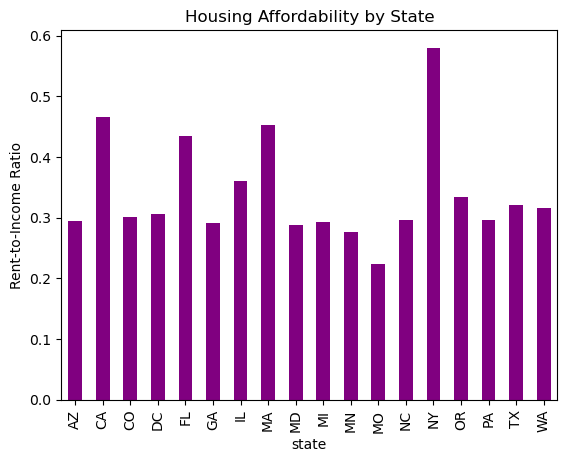

In [28]:
# Compare state-level housing affordability 
affordability= state_trends.iloc[-1]
affordability.plot(kind='bar', color='purple')
plt.title('Housing Affordability by State')
plt.ylabel('Rent-to-Income Ratio')
plt.show()

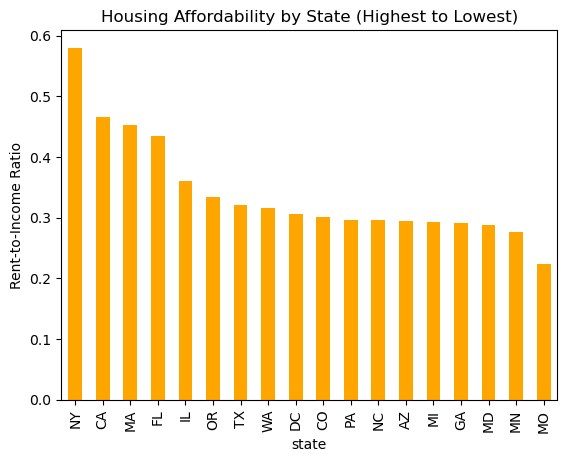

In [29]:
# Create a bar chart comparing the most recent affordability levels across states
latest_affordable_level = state_trends.iloc[-1]
latest_data_sorted = latest_affordable_level.sort_values(ascending=False)
latest_data_sorted.plot(kind='bar', color='orange')
plt.title('Housing Affordability by State (Highest to Lowest)')
plt.ylabel('Rent-to-Income Ratio')
plt.show()


In [31]:
# The states where rent is more than 30% of income
high_rent_states = latest_affordable_level[latest_data_sorted > 0.30]
print("States where rent is unaffordable (>30%):")
print(high_rent_states)

States where rent is unaffordable (>30%):
state
CA    0.465893
CO    0.301595
DC    0.305868
FL    0.434079
IL    0.360784
MA    0.453137
NY    0.580027
OR    0.334371
TX    0.321295
WA    0.316897
Name: 2016-06-30 00:00:00, dtype: float64


In [34]:
# convert into csv 
df.to_csv("Tiered_Affordability_Rental_Cleaned.csv")